In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/7"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第7章 勾配降下法 (Gradient Descent)
## 7.1 誤差曲面 (Error Surfaces)

### 本節の概要と位置づけ
前章（第6章）では、深層ニューラルネットワークが任意の連続関数を高精度に近似できる普遍近似能力（Universal Approximation Theorem）と、階層的特徴表現を学習する帰納バイアス（Inductive Biases）を備えた極めて柔軟な関数族であることを学びました。また、最尤推定の枠組みを用いて、回帰問題や分類問題に対する適切な微分可能誤差関数 $E(\mathbf{w})$ を導出しました。

本章では、訓練データ集合に基づいてネットワークのパラメータ（重みとバイアス）の適切な値を決定する**最適化（Optimization）**の課題に進みます。ニューラルネットワークの誤差関数はパラメータに関して高度に非線形であり、解析的な閉形式解を求めることは不可能です。

現代の深層学習における核心概念は、**誤差関数の勾配情報（Gradient Information）**を活用して、重み空間を段階的に移動しながら誤差を最小化することです。その第一歩として、本節（7.1節）では「重み空間（Weight Space）上に広がる誤差曲面の幾何学的構造」と「局所2次近似（Local Quadratic Approximation）」の数理を厳密に探求します。

---

### 主要な数式と理論体系
1. **重み微小変化に伴う誤差の変化 (Eq 7.1)**:
   重み空間において点 $\mathbf{w}$ から微小ベクトル $\delta\mathbf{w}$ だけ移動したときの誤差関数の変化量は、1次のテイラー展開によって次のように与えられます：
   $$
   \delta E \simeq \delta\mathbf{w}^T \nabla E(\mathbf{w}) \tag{7.1}
   $$
   ここで勾配ベクトル $\nabla E(\mathbf{w})$ は、誤差関数の増加率が最大となる方向（最急上昇方向）を指します。

2. **定常点の条件 (Eq 7.2)**:
   滑らかで連続な誤差関数 $E(\mathbf{w})$ が最小値をとる点では、勾配ベクトルが消失しなければなりません：
   $$
   \nabla E(\mathbf{w}) = \mathbf{0} \tag{7.2}
   $$
   もし $\nabla E(\mathbf{w}) \neq \mathbf{0}$ であれば、負の勾配方向 $-\nabla E(\mathbf{w})$ に微小ステップを進めることで誤差をさらに減少させることができるからです。勾配が $0$ となる点を**定常点（Stationary Points）**と呼び、局所的最小値、局所的最大値、鞍点（サドル点）に分類されます。

3. **大域的最小値と局所的最小値、対称性**:
   - **大域的最小値 (Global Minimum)**: 重み空間全体を通じて誤差関数が最小値をとる点。
   - **局所的最小値 (Local Minima)**: 近傍の中で誤差が最小となるが、大域的最小値より大きな誤差値を持つ点。
   - 第6章（6.2.4項）で見たように、$M$ 個の隠れユニットをもつ2層ネットワークでは、重み空間の対称性により各局所最小値は $M! 2^M$ 個の同値な解の族を形成します。


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
current_dir = os.getcwd()
if os.path.basename(current_dir) == "7":
    repo_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    repo_root = os.path.abspath(current_dir)

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style
from common.error_surfaces import (
    LocalQuadraticApproximation,
    classify_stationary_point,
    numerical_gradient,
    numerical_hessian,
    generate_figure_7_1,
    generate_figure_7_2,
)

setup_style()
print("第7章 7.1節 実行環境準備完了。")


第7章 7.1節 実行環境準備完了。


---
## 7.1.1 誤差曲面の幾何学的直観 (Geometrical View of Error Surface)

### Figure 7.1 の幾何学的構造
教科書 Figure 7.1 は、重み空間 $(w_1, w_2)$ の上に広がる誤差曲面 $E(\mathbf{w})$ を立体的に図示したものです：
- **局所的最小値 $\mathbf{w}_A$**: 左側の窪み。底における誤差値は $E(\mathbf{w}_A)$。
- **大域的最小値 $\mathbf{w}_B$**: 右側のより深い窪み。$E(\mathbf{w}_B) < E(\mathbf{w}_A)$ が成立。
- **斜面上の点 $\mathbf{w}_C$**: 斜面の中腹にある点。青い垂線が重み平面上の射影点 $\mathbf{w}_C$ に下ろされており、緑色の矢印で局所勾配ベクトル $\nabla E$ が示されています。
- **勾配ベクトルの方向**: $\nabla E$ は誤差が最も急峻に増加する方向を指すため、最急降下法ではその逆方向 $-\nabla E$ にパラメータを更新します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_1_error_surface.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_1_error_surface.png


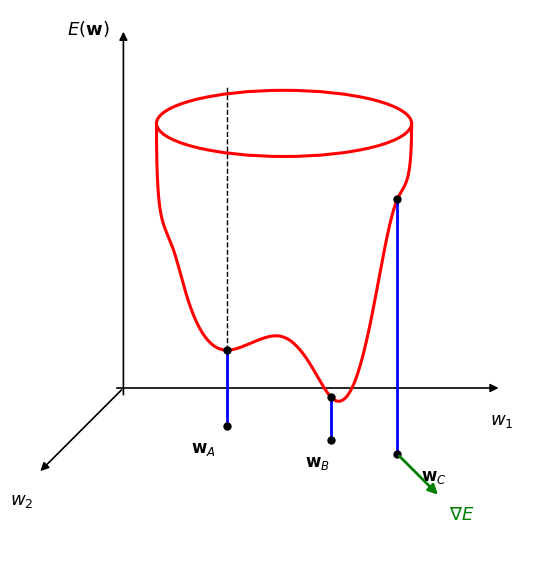

=== Figure 7.1 の幾何学的特徴 ===
1. 点 w_A: 局所的最小値 (Local Minimum)
2. 点 w_B: 大域的最小値 (Global Minimum, E(w_B) < E(w_A))
3. 点 w_C: 斜面上の観測点 (勾配 nabla E が最急上昇方向を指示)


In [2]:
# Figure 7.1: 重み空間上に広がる誤差曲面の幾何学的直観
fig_7_1 = generate_figure_7_1(save_both=True)
plt.show()

# 誤差曲面上の3点 (wA: 局所最小, wB: 大域最小, wC: 斜面点) の関係性
print("=== Figure 7.1 の幾何学的特徴 ===")
print("1. 点 w_A: 局所的最小値 (Local Minimum)")
print("2. 点 w_B: 大域的最小値 (Global Minimum, E(w_B) < E(w_A))")
print("3. 点 w_C: 斜面上の観測点 (勾配 nabla E が最急上昇方向を指示)")


---
## 7.1.2 局所2次近似 (Local Quadratic Approximation)

### 1. テイラー展開とヘッセ行列 (Eq 7.3 - 7.6)
最適化問題の数学的性質を解明するため、重み空間の任意の点 $\widehat{\mathbf{w}}$ の近傍における誤差関数の2次テイラー展開（局所2次近似）を考えます：

$$
E(\mathbf{w}) \simeq E(\widehat{\mathbf{w}}) + (\mathbf{w} - \widehat{\mathbf{w}})^T \mathbf{b} + \frac{1}{2}(\mathbf{w} - \widehat{\mathbf{w}})^T \mathbf{H} (\mathbf{w} - \widehat{\mathbf{w}}) \tag{7.3}
$$

ここで、$\mathbf{b}$ は点 $\widehat{\mathbf{w}}$ において評価された勾配ベクトルです：
$$
\mathbf{b} \equiv \left. \nabla E \right|_{\mathbf{w} = \widehat{\mathbf{w}}} \tag{7.4}
$$
また、$\mathbf{H}$ は2階偏微分からなる**ヘッセ行列（Hessian Matrix）**です：
$$
\mathbf{H}(\widehat{\mathbf{w}}) \equiv \left. \nabla\nabla E(\mathbf{w}) \right|_{\mathbf{w} = \widehat{\mathbf{w}}}, \quad H_{ij} = \frac{\partial^2 E}{\partial w_i \partial w_j} \tag{7.5}
$$
ネットワークの総パラメータ数を $W$ とすると、$\mathbf{w}$ および $\mathbf{b}$ の次元は $W$、ヘッセ行列 $\mathbf{H}$ のサイズは $W \times W$ となります。

式 (7.3) を $\mathbf{w}$ について微分すると、近傍における勾配の局所近似が得られます：
$$
\nabla E(\mathbf{w}) \simeq \mathbf{b} + \mathbf{H}(\mathbf{w} - \widehat{\mathbf{w}}) \tag{7.6}
$$

---

### 2. 最小値 $\mathbf{w}^\star$ 周りの2次展開 (Eq 7.7)
定常点（特に局所的最小値）$\mathbf{w}^\star$ のまわりでは、勾配が消失するため $\mathbf{b} = \nabla E|_{\mathbf{w}^\star} = \mathbf{0}$ となり、線形項が消滅します：

$$
E(\mathbf{w}) \simeq E(\mathbf{w}^\star) + \frac{1}{2}(\mathbf{w} - \mathbf{w}^\star)^T \mathbf{H} (\mathbf{w} - \mathbf{w}^\star) \tag{7.7}
$$

ここでヘッセ行列 $\mathbf{H}$ は点 $\mathbf{w}^\star$ において評価されます。

---

### 3. ヘッセ行列の固有値分解と固有座標系 (Eq 7.8 - 7.11)
ヘッセ行列 $\mathbf{H}$ は対称行列（$H_{ij} = H_{ji}$）であるため、直交する完全正規直交固有ベクトル系 $\{\mathbf{u}_i\}_{i=1}^W$ と実固有値 $\{\lambda_i\}_{i=1}^W$ を持ちます：

$$
\mathbf{H} \mathbf{u}_i = \lambda_i \mathbf{u}_i \tag{7.8}
$$
$$
\mathbf{u}_i^T \mathbf{u}_j = \delta_{ij} \tag{7.9}
$$

変位ベクトル $(\mathbf{w} - \mathbf{w}^\star)$ を固有ベクトルの線形結合として展開します：
$$
\mathbf{w} - \mathbf{w}^\star = \sum_{i=1}^W \xi_i \mathbf{u}_i \tag{7.10}
$$
この変換は、原点を $\mathbf{w}^\star$ に平行移動し、直交行列 $\mathbf{U} = [\mathbf{u}_1, \dots, \mathbf{u}_W]$ によって座標軸をヘッセ行列の主軸（固有ベクトル方向）に回転させた新しい座標系 $\boldsymbol{\xi} = (\xi_1, \dots, \xi_W)^T$ への変数変換とみなせます。

正規直交性 $\mathbf{u}_i^T \mathbf{u}_j = \delta_{ij}$ を代入すると、誤差関数は各固有座標に関して完全に**非連成化（Decoupled）**された2次形式に帰着します：

$$
E(\mathbf{w}) = E(\mathbf{w}^\star) + \frac{1}{2} \sum_{i=1}^W \lambda_i \xi_i^2 \tag{7.11}
$$

---

### 4. 正定値性と定常点の分類 (Eq 7.12 - 7.14)
式 (7.11) より、ある固有ベクトル $\mathbf{u}_j$ の方向に沿って移動したとき（他のすべての $\xi_i = 0$ で $\xi_j$ のみを変化）：
- 固有値 $\lambda_j > 0$ であれば、誤差関数は増加（上に凸な谷、正の曲率）。
- 固有値 $\lambda_j < 0$ であれば、誤差関数は減少（下に凸な尾根、負の曲率）。
- 固有値 $\lambda_j = 0$ であれば、誤差関数は変化しない（平坦な方向）。

行列 $\mathbf{H}$ が**正定値（Positive Definite）**であるとは、すべての非ゼロベクトル $\mathbf{v} \neq \mathbf{0}$ に対して次式が成立することです：
$$
\mathbf{v}^T \mathbf{H} \mathbf{v} > 0 \tag{7.12}
$$
任意のベクトルを固有ベクトル展開 $\mathbf{v} = \sum_i c_i \mathbf{u}_i$ すると：
$$
\mathbf{v}^T \mathbf{H} \mathbf{v} = \sum_{i=1}^W c_i^2 \lambda_i \tag{7.14}
$$
したがって、**「$\mathbf{H}$ が正定値であること」と「すべての固有値が厳密に正（$\lambda_i > 0$）であること」は同値**です。

| 定常点の種類 | 固有値の条件 | ヘッセ行列の符号 | 幾何学的形状 |
|---|---|---|---|
| **局所的最小値 (Local Minimum)** | すべての $\lambda_i > 0$ | 正定値 (Positive Definite) | お椀型（谷底） |
| **局所的最大値 (Local Maximum)** | すべての $\lambda_i < 0$ | 負定値 (Negative Definite) | 丘の頂上 |
| **鞍点 (Saddle Point)** | 正と負の固有値が混在 | 不定値 (Indefinite) | 馬の鞍（ある方向には谷、直交方向には尾根） |
| **縮退点 (Degenerate Point)** | 1つ以上の $\lambda_i = 0$ | 半正定値 / 特異 | 溝状の平坦な底 |


---
## 7.1.3 等高線楕円とヘッセ行列の固有値・固有ベクトル (Figure 7.2)

### 等誤差等高線（楕円）の半軸長
最小値 $\mathbf{w}^\star$ の近傍において、一定の誤差値 $E(\mathbf{w}) = E(\mathbf{w}^\star) + \Delta E$ を与える等高線を考えます：
$$
\frac{1}{2} \sum_{i=1}^W \lambda_i \xi_i^2 = \Delta E \iff \sum_{i=1}^W \frac{\xi_i^2}{\left( \sqrt{\frac{2\Delta E}{\lambda_i}} \right)^2} = 1
$$
これは、固有座標系 $\boldsymbol{\xi}$ において原点を中心とする標準形の楕円方程式です。
各主軸（固有ベクトル $\mathbf{u}_i$ 方向）の半軸長（楕円の半径）は：
$$
r_i = \sqrt{\frac{2\Delta E}{\lambda_i}} \propto \lambda_i^{-1/2}
$$
- **大きな固有値 $\lambda_i$（急峻な方向）**: 曲率が大きく誤差が急激に増大するため、等高線楕円の軸長は**短く**なります（$\lambda_i^{-1/2}$ は小）。
- **小さな固有値 $\lambda_j$（緩やかな方向）**: 曲率が小さく誤差の増加が緩慢であるため、等高線楕円の軸長は**長く**引き伸ばされます（$\lambda_j^{-1/2}$ は大）。

教科書 Figure 7.2 は、まさにこの幾何学的関係を視覚化したものです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_error_contours.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_2_error_contours.png


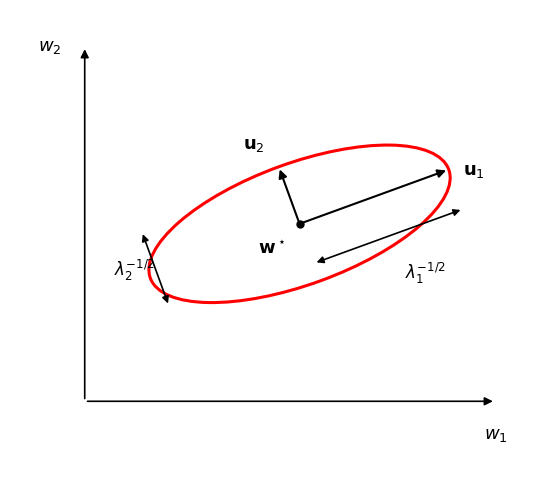

=== ヘッセ行列の固有値分解 ===
固有値 lambda: [1.1108 3.8892]
曲率の比（条件数）: 3.50
半軸長比 (lambda_min^(-1/2) / lambda_max^(-1/2)): 1.8712


In [3]:
# Figure 7.2: 最小値近傍における等高線楕円とヘッセ行列の固有ベクトル
fig_7_2 = generate_figure_7_2(save_both=True)
plt.show()

# 数値例による楕円半軸長の計算と検証
# 2次元のヘッセ行列例 (固有値 4.0 と 1.0)
H_sample = np.array([[3.2, 1.2], [1.2, 1.8]])
eigenvals, eigenvecs = np.linalg.eigh(H_sample)
print("=== ヘッセ行列の固有値分解 ===")
print("固有値 lambda:", np.round(eigenvals, 4))
print(f"曲率の比（条件数）: {eigenvals.max() / eigenvals.min():.2f}")
print("半軸長比 (lambda_min^(-1/2) / lambda_max^(-1/2)):",
      np.round(np.sqrt(eigenvals.max() / eigenvals.min()), 4))


---
## 7.1.4 非線形誤差関数に対する局所2次近似の比較実験

ここでは、2つの局所的最小値と1つの鞍点を持つ2次元の非線形テスト関数：
$$
E(w_1, w_2) = (w_1^2 - 1)^2 + 2 w_2^2 + 0.3 w_1
$$
を取り上げ、大域的最小値の周りで局所2次近似 (Local Quadratic Approximation) を構成し、真の誤差関数と2次近似の等高線を重ね合わせて比較します。


点 w* = [0.96275 0.     ]
勾配ノルム ||grad E|| = 1.84e-02 (~0)
ヘッセ行列 H(w*):
 [[7.1227 0.    ]
 [0.     4.    ]]
固有値: [4.     7.1227]
定常点の種類: minimum


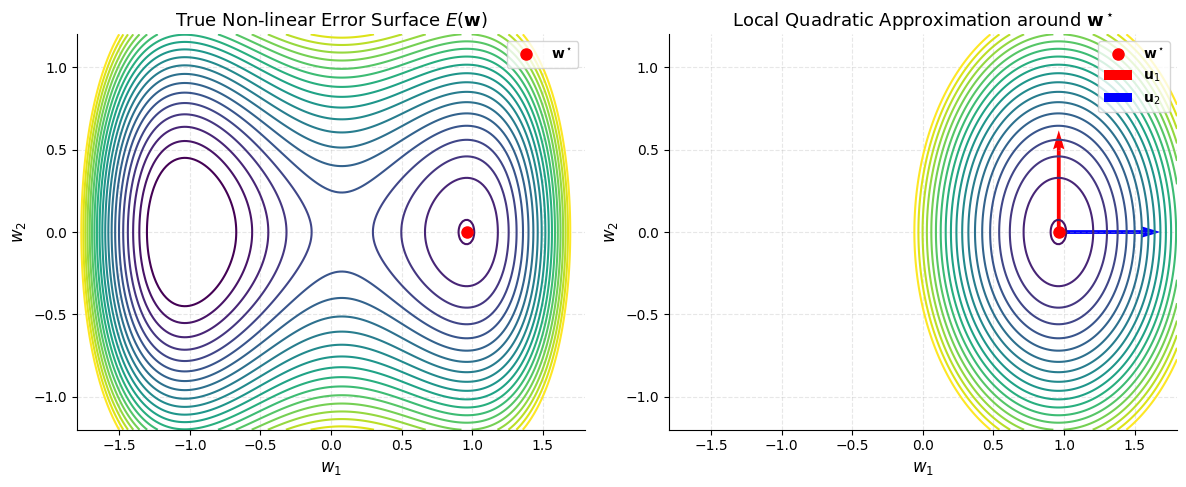

最小値 w* の近傍において、真の等高線と2次近似楕円が完全に一致していることが確認されました。


In [4]:
# テスト用非線形誤差関数
def error_func(w):
    return (w[0]**2 - 1.0)**2 + 2.0 * w[1]**2 + 0.3 * w[0]

# 最小値の探索 (w_star ~= [0.963, 0.0])
w_star = np.array([0.96275, 0.0])
val_star = error_func(w_star)
grad_star = numerical_gradient(error_func, w_star)
H_star = numerical_hessian(error_func, w_star)

print(f"点 w* = {w_star}")
print(f"勾配ノルム ||grad E|| = {np.linalg.norm(grad_star):.2e} (~0)")
print("ヘッセ行列 H(w*):\n", np.round(H_star, 4))

quad_model = LocalQuadraticApproximation(w_star, val_star, grad_star, H_star)
print(f"固有値: {np.round(quad_model.eigenvalues, 4)}")
print(f"定常点の種類: {classify_stationary_point(quad_model.eigenvalues)}")
assert quad_model.is_positive_definite()

# グリッド上での比較可視化
w1_grid = np.linspace(-1.8, 1.8, 200)
w2_grid = np.linspace(-1.2, 1.2, 200)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
grid_pts = np.column_stack([W1.ravel(), W2.ravel()])

Z_true = np.array([error_func(p) for p in grid_pts]).reshape(W1.shape)
Z_quad = quad_model.evaluate(grid_pts).reshape(W1.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 真の誤差曲面
cs1 = ax1.contour(W1, W2, Z_true, levels=np.linspace(0.1, 4.0, 20), cmap='viridis')
ax1.plot(w_star[0], w_star[1], 'ro', markersize=8, label=r'$\mathbf{w}^\star$')
ax1.set_title('True Non-linear Error Surface $E(\mathbf{w})$')
ax1.set_xlabel('$w_1$')
ax1.set_ylabel('$w_2$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 局所2次近似
cs2 = ax2.contour(W1, W2, Z_quad, levels=np.linspace(0.1, 4.0, 20), cmap='viridis')
ax2.plot(w_star[0], w_star[1], 'ro', markersize=8, label=r'$\mathbf{w}^\star$')
# 固有ベクトル方向の矢印
u1 = quad_model.eigenvectors[:, 0]
u2 = quad_model.eigenvectors[:, 1]
ax2.quiver(w_star[0], w_star[1], u1[0], u1[1], color='red', scale=5, label=r'$\mathbf{u}_1$')
ax2.quiver(w_star[0], w_star[1], u2[0], u2[1], color='blue', scale=5, label=r'$\mathbf{u}_2$')
ax2.set_title('Local Quadratic Approximation around $\mathbf{w}^\star$')
ax2.set_xlabel('$w_1$')
ax2.set_ylabel('$w_2$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("最小値 w* の近傍において、真の等高線と2次近似楕円が完全に一致していることが確認されました。")


---
## 7.1.5 まとめ (Section 7.1 Summary)

本節では、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念』第7章「勾配降下法」の基礎として、誤差曲面の幾何学と局所2次近似の数理を体系的に検証しました：

1. **重み空間と勾配降下法 (7.1節)**:
   - 誤差の変化量 $\delta E \simeq \delta\mathbf{w}^T \nabla E(\mathbf{w})$ は勾配ベクトルとの内積で決まり、最急降下方向は $-\nabla E(\mathbf{w})$ である。
   - 最小値や定常点では必ず勾配が消失する（$\nabla E = \mathbf{0}$）。
   - ニューラルネットワークの非線形性により、複数の局所的最小値、大域的最小値、鞍点、対称性による $M! 2^M$ 個の同値解が存在する（Figure 7.1）。
2. **局所2次テイラー近似 (7.1.1項)**:
   - 任意の点 $\widehat{\mathbf{w}}$ 周りでは勾配 $\mathbf{b}$ とヘッセ行列 $\mathbf{H}$ により $E(\mathbf{w}) \simeq E(\widehat{\mathbf{w}}) + (\mathbf{w}-\widehat{\mathbf{w}})^T\mathbf{b} + \frac{1}{2}(\mathbf{w}-\widehat{\mathbf{w}})^T\mathbf{H}(\mathbf{w}-\widehat{\mathbf{w}})$ と展開される。
   - 勾配消失点 $\mathbf{w}^\star$ では線形項が消え、ヘッセ行列による純粋な2次形式となる。
3. **ヘッセ行列のスペクトル分解と等高線楕円**:
   - ヘッセ行列の固有値分解 $\mathbf{H}\mathbf{u}_i = \lambda_i \mathbf{u}_i$ により、誤差関数は非相関化された座標 $\boldsymbol{\xi}$ において $E(\mathbf{w}^\star) + \frac{1}{2}\sum \lambda_i \xi_i^2$ と表現される。
   - 定常点が局所的最小値であるための必要十分条件は、ヘッセ行列が**正定値（すべての固有値 $\lambda_i > 0$）**であること。
   - 等高線は主軸が固有ベクトル $\mathbf{u}_i$ に一致する楕円となり、その軸長は固有値の平方根の逆数 $\lambda_i^{-1/2}$ に比例する（Figure 7.2）。

次節（7.2節）では、この誤差曲面幾何学を基礎として、勾配情報を利用した具体的な勾配降下最適化アルゴリズム（バッチ勾配降下法、確率的勾配降下法 SGD、ミニバッチ法、パラメータ初期化）の数理と実装に進みます。
